# Project Introduction

This project implements a **Price Plan Recommendation System** that designs and recommends customized mobile tariff plans based on real customer usage patterns.

### Objective
To help a telecom operator:
* **Create new tariff plans** that reflect the real calling behavior of customers.
* **Recommend the top 3 best-fit plans** to each customer from a limited set of plans (not exceeding 25 in total).

### Approach
1. **Data Exploration & Cleaning**  
   Analyze the Call Detail Records (CDR) dataset to understand voice usage across day, evening, night, and international calls.
2. **Customer Segmentation**  
   Apply clustering (K-Means) to group customers with similar usage habits.
3. **Plan Design**  
   Generate realistic postpaid plans from cluster profiles, using existing market tariffs as reference points.
4. **Recommendation Engine**  
   Use both a distance-based method and an XGBoost model to recommend the top 3 suitable plans for each customer.

### Outcome
The system provides a concise list of optimized plans that balance customer needs with operator revenue goals, ensuring every user receives accurate, data-driven plan suggestions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import shap
import xgboost as xgb
from sklearn.metrics.pairwise import euclidean_distances

## Data Loading and Pre-Processing

The dataset `CDR-Call-Details.csv` contains call usage metrics (day, evening, night, international minutes) along with churn and service information.

Steps performed:
- Loaded data with `pandas`.
- Removed duplicates and filled missing values with zeros.
- Engineered features such as **Total Minutes**, usage percentages (`Pct_Day`, `Pct_Eve`, etc.), and **Intensity metrics** (calls per minute for each period).

These transformations prepare the dataset for meaningful visualization and modeling.


In [ ]:
# Load data
df = pd.read_csv("CDR-Call-Details.csv")


In [ ]:

# Clean data
df = df.fillna(0)
df = df.drop_duplicates()

In [ ]:
df['Total Mins'] = df[['Day Mins','Eve Mins','Night Mins','Intl Mins']].sum(axis=1)
df['Pct_Day'] = df['Day Mins'] / df['Total Mins'].replace(0, 1)
df['Pct_Eve'] = df['Eve Mins'] / df['Total Mins'].replace(0, 1)
df['Pct_Night'] = df['Night Mins'] / df['Total Mins'].replace(0, 1)
df['Pct_Intl'] = df['Intl Mins'] / df['Total Mins'].replace(0, 1)

df['Day_Intensity'] = df['Day Calls'] / (df['Day Mins'] + 1e-6)
df['Eve_Intensity'] = df['Eve Calls'] / (df['Eve Mins'] + 1e-6)
df['Night_Intensity'] = df['Night Calls'] / (df['Night Mins'] + 1e-6)
df['Intl_Intensity'] = df['Intl Calls'] / (df['Intl Mins'] + 1e-6)

## Exploratory Data Analysis (EDA)

EDA highlighted key patterns:
- **Total Usage Distribution:** Most customers stay under ~5000 total minutes.
- **Time-of-Day Ratios:** Evening minutes dominate average usage (600 mins), followed by day and night (500 - 600 mins), while international usage is very low (50 mins).
- **Churn Rate:** Around 10–11% of customers churn. Higher international usage and frequent customer service calls show a mild positive correlation with churn.

These insights guide both pricing strategy and customer retention efforts.


In [ ]:
# Caps for visualization
day_cap = np.percentile(df['Day Mins'], 99)
intl_cap = np.percentile(df['Intl Mins'], 99)
total_cap = np.percentile(df['Total Mins'], 99)

In [ ]:
All_required_features = ['Day Mins','Eve Mins','Night Mins','Intl Mins',
    'Pct_Day', 'Pct_Eve', 'Pct_Night', 'Pct_Intl',
    'Day_Intensity', 'Eve_Intensity', 'Night_Intensity', 'Intl_Intensity',
    'Total Mins'
]

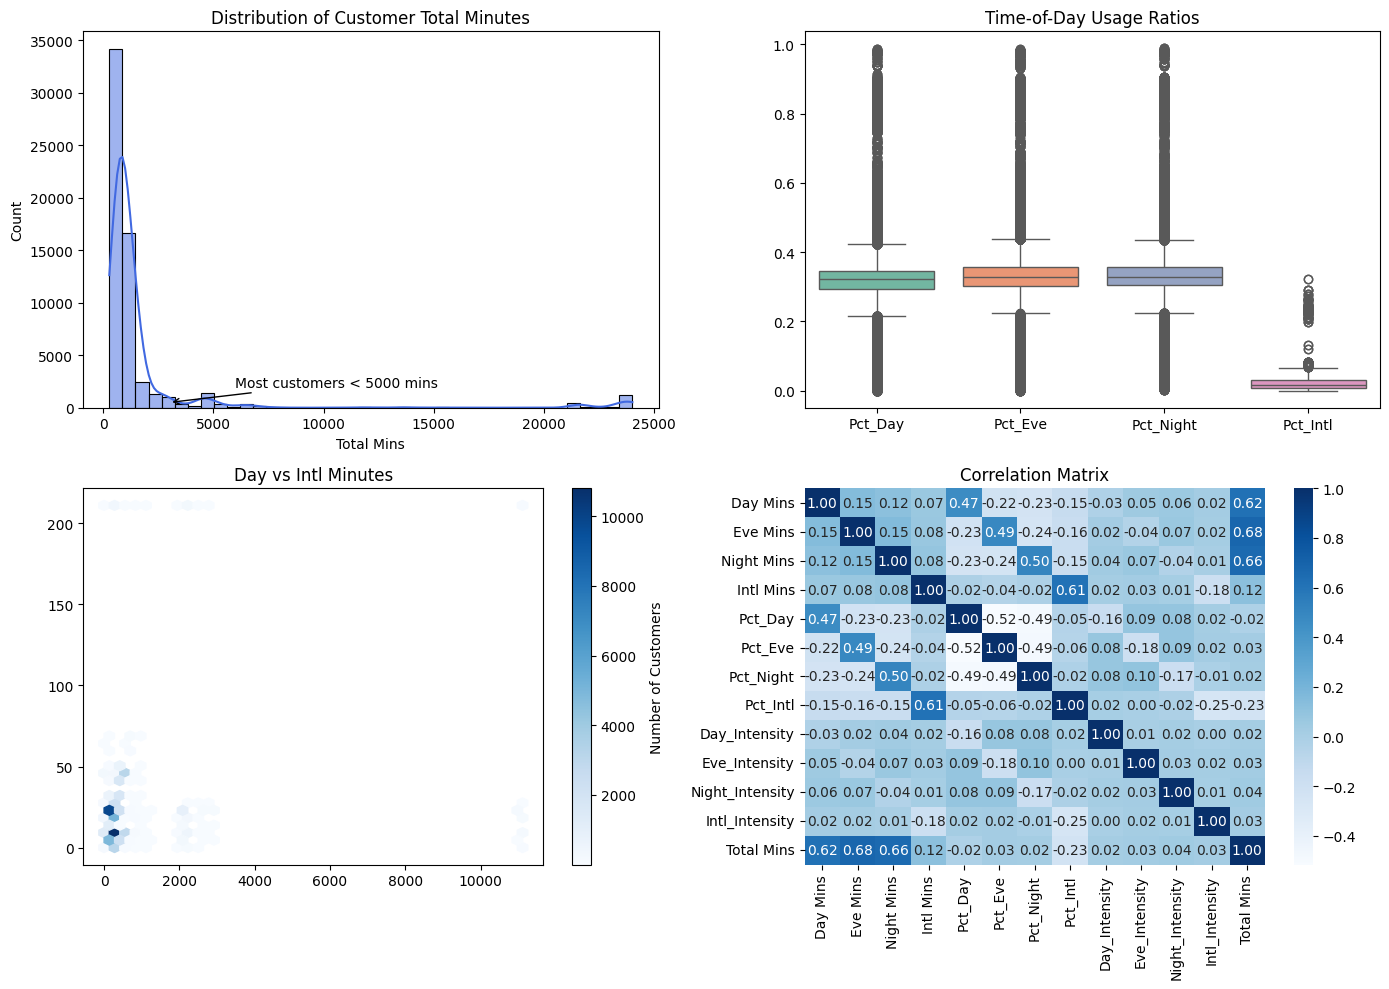

In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Total Mins'].clip(upper=total_cap), bins=40, kde=True, color="royalblue", ax=axes[0,0])
axes[0,0].set_title("Distribution of Customer Total Minutes")
axes[0,0].annotate("Most customers < 5000 mins", xy=(3000, 500), xytext=(6000, 2000), arrowprops=dict(arrowstyle="->"))

sns.boxplot(data=df[['Pct_Day','Pct_Eve','Pct_Night','Pct_Intl']], ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Time-of-Day Usage Ratios")

hb = axes[1,0].hexbin(df['Day Mins'].clip(upper=day_cap), df['Intl Mins'].clip(upper=intl_cap), gridsize=40, cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=axes[1,0], label="Number of Customers")
axes[1,0].set_title("Day vs Intl Minutes")

sns.heatmap(df[All_required_features].corr(), annot=True, fmt=".2f", cmap="Blues", ax=axes[1,1])
axes[1,1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

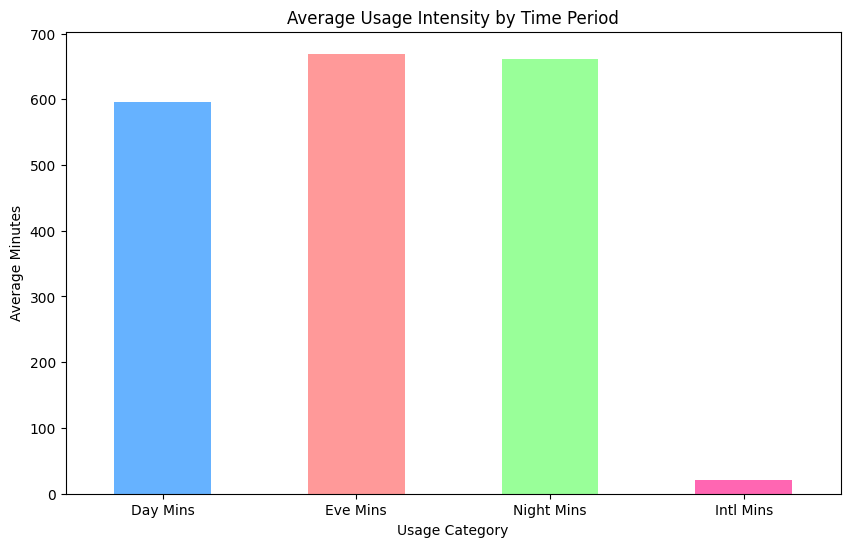

In [ ]:
# Average usage bar plot
usage_cols = ['Day Mins', 'Eve Mins', 'Night Mins', 'Intl Mins']
df[usage_cols] = df[usage_cols].fillna(0)

avg_usage = df[usage_cols].mean()
plt.figure(figsize=(10, 6))
avg_usage.plot(kind='bar', color=['#66B2FF', '#FF9999', '#99FF99', '#FF66B2'])
plt.title('Average Usage Intensity by Time Period')
plt.xlabel('Usage Category')
plt.ylabel('Average Minutes')
plt.xticks(rotation=0)
plt.show()

Churn percentage:
 Churn
False    88.953594
True     11.046406
Name: proportion, dtype: float64


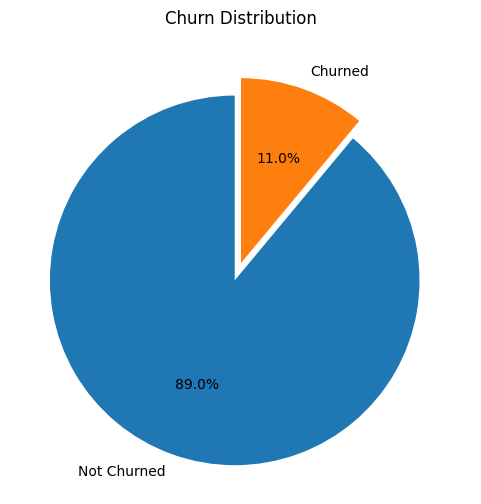

Insights: Here we got that around 10.4% are churners!!


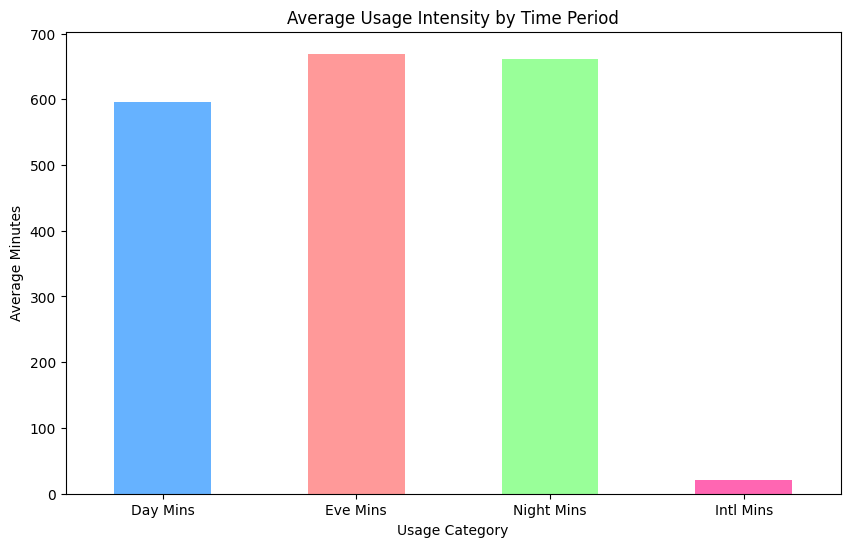

 Insights:
Highest Intensity: Evening Minutes (Eve Mins) show the highest average usage (~600 minutes), indicating peak customer intensity during this period.
Moderate Usage: Day Minutes (Day Mins) and Night Minutes (Night Mins) have similar moderate intensity (~500-600 minutes), suggesting consistent daytime and off-peak usage.
Low Intensity: International Minutes (Intl Mins) are significantly lower (~50 minutes), reflecting minimal international usage intensity.


/tmp/ipython-input-2165030000.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Churn', y='CustServ Calls', palette=['#66B2FF', '#FF9999'], errorbar=None)


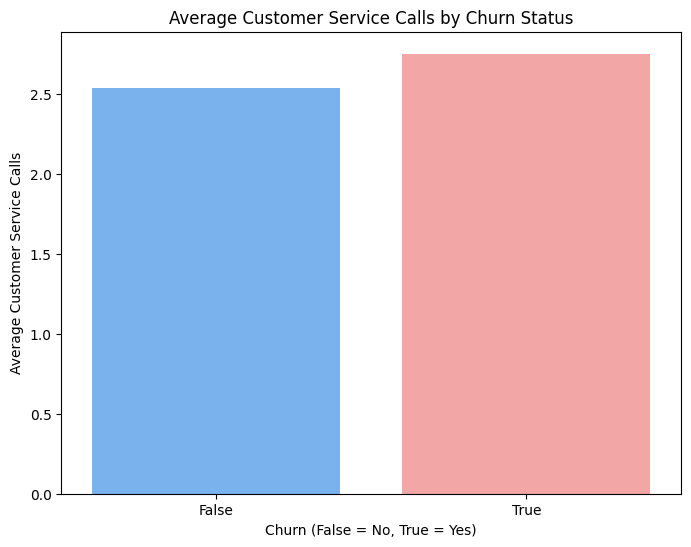

Insights:it suggests that frequent customer service interactions (e.g., due to issues) might be a reason for churn.


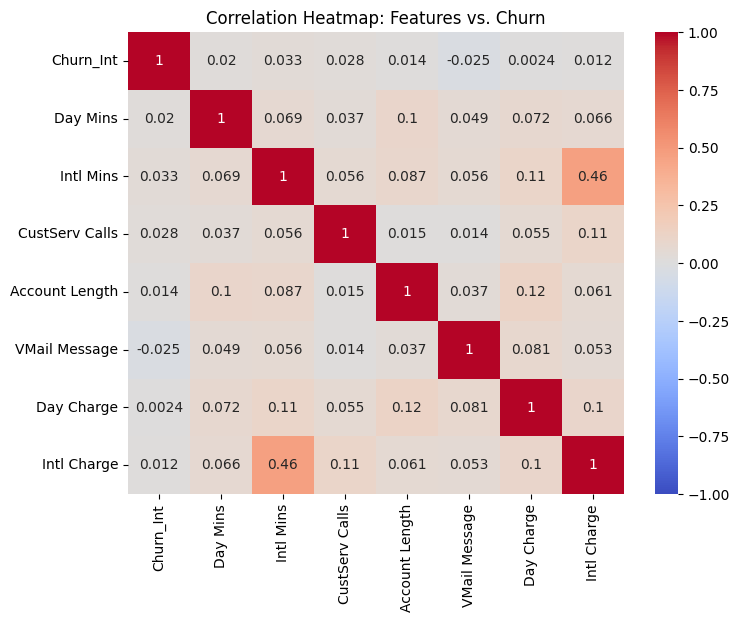

Insights:
International Minutes (Intl Mins: 0.036)**: Slightly higher usage correlates with churn, suggesting cost or service quality issues.
Customer Service Calls (CustServ Calls: 0.028)**: Frequent calls indicate minor dissatisfaction, a potential churn driver.
Voicemail Message (VMail Message: -0.025)**: Slight negative correlation suggests voicemail users are less likely to churn.


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("Churn percentage:\n", churn_percent)

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=churn_counts.index.map({True: "Churned", False: "Not Churned"}),
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0)
)
plt.title("Churn Distribution")
plt.show()
print("Insights: Here we got that around 10.4% are churners!!")
usage_cols = ['Day Mins', 'Eve Mins', 'Night Mins', 'Intl Mins']
df[usage_cols] = df[usage_cols].fillna(0)
import seaborn as sns
import matplotlib.pyplot as plt

# Fill missing values
usage_cols = ['Day Mins', 'Eve Mins', 'Night Mins', 'Intl Mins']
df[usage_cols] = df[usage_cols].fillna(0)

# Calculate average usage
avg_usage = df[usage_cols].mean()

# bar plot
plt.figure(figsize=(10, 6))
avg_usage.plot(kind='bar', color=['#66B2FF', '#FF9999', '#99FF99', '#FF66B2'])
plt.title('Average Usage Intensity by Time Period')
plt.xlabel('Usage Category')
plt.ylabel('Average Minutes')
plt.xticks(rotation=0)
plt.show()
print(""" Insights:
Highest Intensity: Evening Minutes (Eve Mins) show the highest average usage (~600 minutes), indicating peak customer intensity during this period.
Moderate Usage: Day Minutes (Day Mins) and Night Minutes (Night Mins) have similar moderate intensity (~500-600 minutes), suggesting consistent daytime and off-peak usage.
Low Intensity: International Minutes (Intl Mins) are significantly lower (~50 minutes), reflecting minimal international usage intensity.""")
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Churn', y='CustServ Calls', palette=['#66B2FF', '#FF9999'], errorbar=None)
plt.title('Average Customer Service Calls by Churn Status')
plt.xlabel('Churn (False = No, True = Yes)')
plt.ylabel('Average Customer Service Calls')
plt.show()
print("Insights:it suggests that frequent customer service interactions (e.g., due to issues) might be a reason for churn.")
df['Churn_Int'] = df['Churn'].astype(int)  # 1 for True, 0 for False
corr_matrix = df[['Churn_Int', 'Day Mins', 'Intl Mins', 'CustServ Calls', 'Account Length', 'VMail Message', 'Day Charge', 'Intl Charge']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Features vs. Churn')
plt.show()
print("""Insights:
International Minutes (Intl Mins: 0.036)**: Slightly higher usage correlates with churn, suggesting cost or service quality issues.
Customer Service Calls (CustServ Calls: 0.028)**: Frequent calls indicate minor dissatisfaction, a potential churn driver.
Voicemail Message (VMail Message: -0.025)**: Slight negative correlation suggests voicemail users are less likely to churn.""")

# EDA Report (Churn Analysis)

## 1. Churn Overview
- Churn Rate: ~10.4% of customers churn.
- Majority stay, but churn is still a concern.

## 2. Usage Patterns
- Evening Minutes (~600 mins): Highest usage.
- Day & Night Minutes (~500–600 mins): Moderate, consistent usage.
- International Minutes (~50 mins): Lowest usage.

## 3. Churn Correlations
- Intl Mins (0.036): Slight positive correlation with churn, likely cost/quality issues.
- CustServ Calls (0.028): More calls linked to churn, indicates dissatisfaction.
- VMail Message (-0.025): Slight negative correlation, voicemail users less likely to churn.

## 4. Insights and Actions
- Churn Drivers: High international usage and frequent service calls.
- Business Focus: Improve international plans, enhance customer service, and leverage evening usage with offers.


## Customer Segmentation

To design plan tiers, we grouped customers using **K-Means clustering** on usage features and time-of-day percentages.

- Optimal clusters (k=6) chosen via the **Elbow method** and Silhouette score (~0.54).
- Each cluster represents a distinct usage pattern (e.g., heavy evening users, international callers).

Cluster profiles drive the creation of realistic plan offerings.


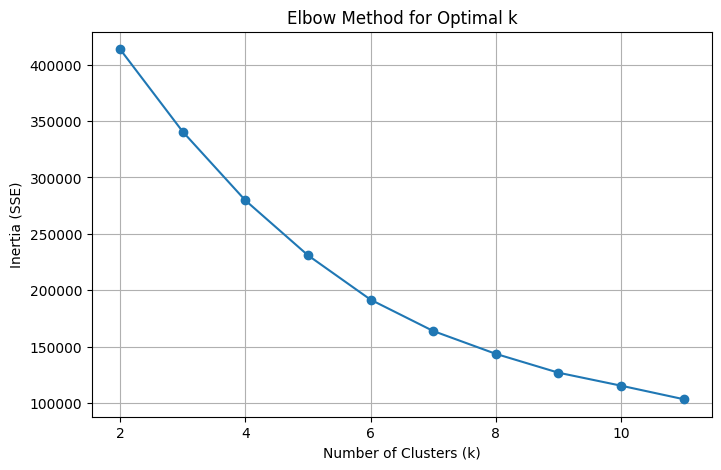

In [ ]:
# Clustering Setup
cluster_features = usage_cols + ['Pct_Day','Pct_Eve','Pct_Night','Pct_Intl']

inertias = []
K_range = range(2, 12)
scaler_plan = StandardScaler()
X_scaled_full = scaler_plan.fit_transform(df[cluster_features].fillna(0))

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_full)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


Plan Design: 30222, Train: 18133, Val: 6045, Test: 6045
Clusters: 6, Silhouette Score: 0.545


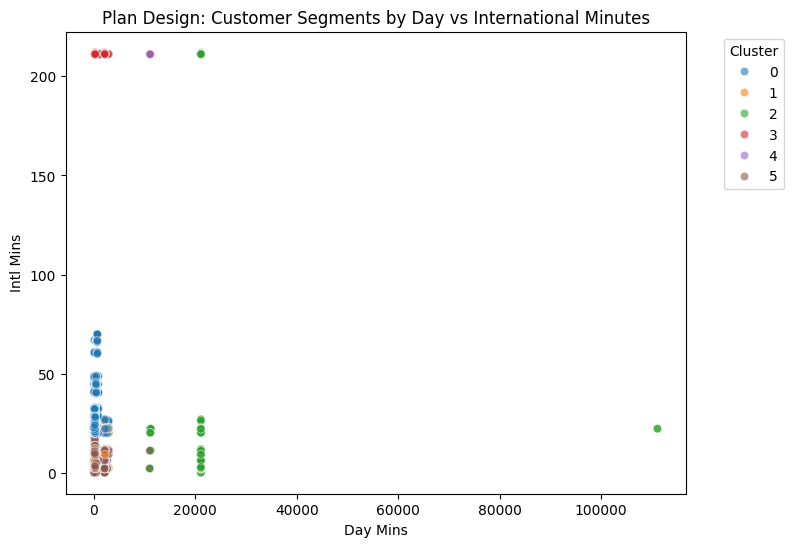

In [ ]:
# Split data
n_clusters = 6
df_plan, df_temp = train_test_split(df, test_size=0.5, random_state=42)
df_train, df_temp2 = train_test_split(df_temp, test_size=0.4, random_state=42)
df_val, df_test = train_test_split(df_temp2, test_size=0.5, random_state=42)

print(f"Plan Design: {len(df_plan)}, Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# Cluster customers for plan design
X_plan = df_plan[usage_cols].fillna(0)
scaler_plan = StandardScaler()
X_scaled_plan = scaler_plan.fit_transform(X_plan)

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_plan['segment'] = kmeans.fit_predict(X_scaled_plan)

# Save centroids
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler_plan.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=usage_cols)
centroids_df.index = [f"Cluster_{i}" for i in range(n_clusters)]

sil_score = silhouette_score(X_scaled_plan, df_plan['segment'])
print(f"Clusters: {n_clusters}, Silhouette Score: {sil_score:.3f}")

# Plot segments
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_plan['Day Mins'], y=df_plan['Intl Mins'], hue=df_plan['segment'], palette="tab10", alpha=0.6)
plt.title("Plan Design: Customer Segments by Day vs International Minutes")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



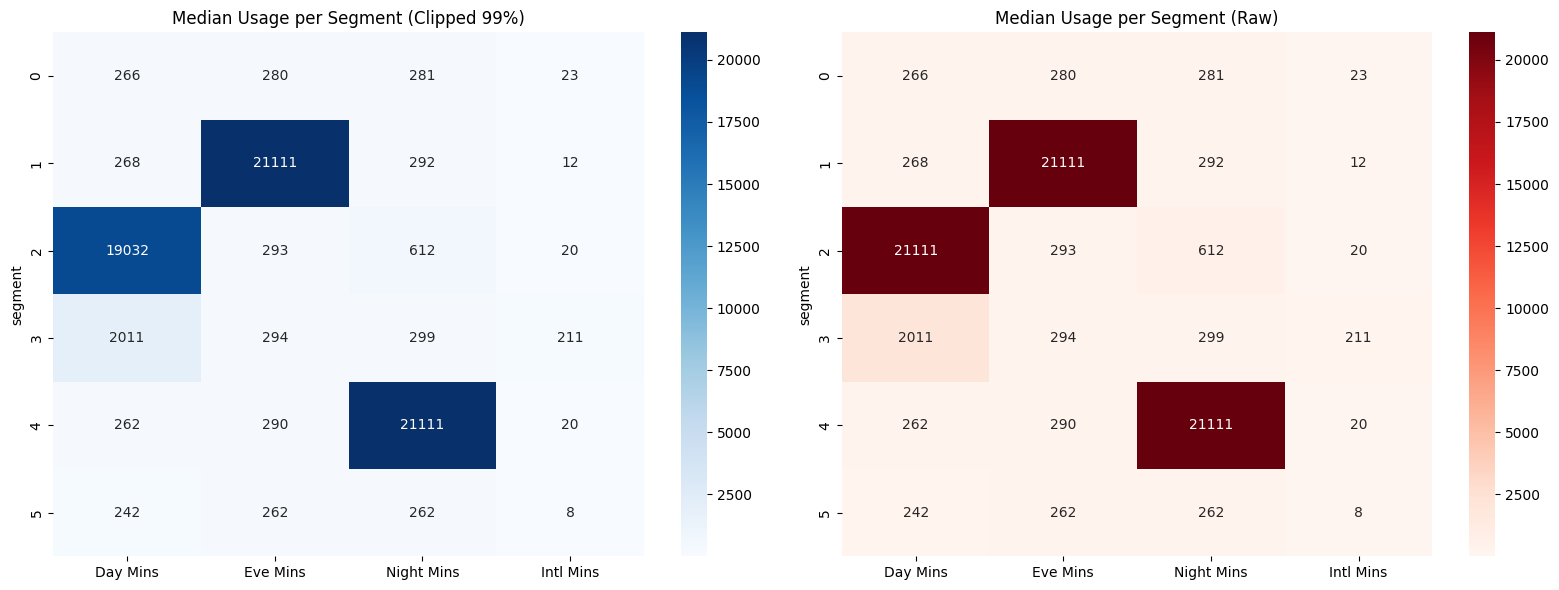

In [ ]:
# Show cluster profiles
df_clipped = df_plan.copy()
for col in usage_cols:
    df_clipped[col] = df_clipped[col].clip(upper=df_clipped[col].quantile(0.99))

fig, axs = plt.subplots(1, 2, figsize=(16,6))
cluster_profile_clipped = df_clipped.groupby('segment')[usage_cols].median()
sns.heatmap(cluster_profile_clipped, annot=True, fmt=".0f", cmap="Blues", ax=axs[0])
axs[0].set_title("Median Usage per Segment (Clipped 99%)")

cluster_profile_raw = df_plan.groupby('segment')[usage_cols].median()
sns.heatmap(cluster_profile_raw, annot=True, fmt=".0f", cmap="Reds", ax=axs[1])
axs[1].set_title("Median Usage per Segment (Raw)")

plt.tight_layout()
plt.show()


## Tariff Plan Design

For each cluster:
- Generated two tailored **Postpaid plans** (“Value” and “Comfort”) by using median cluster usage.
- Adjusted included minutes for day, evening, night, and international calls.
- Applied price tiers (₹99–₹1999) ensuring practical monthly fees.

Additionally, three **generic plans** (Lite, PowerUser, IntlSaver) provide baseline choices for atypical users.


In [ ]:
# Pricing Configuration
PRICE_TIERS = [99, 199, 299, 399,349,449,499,549,599,799,899, 999,1299, 1499, 1999,2999]
POPULAR_TIERS = {99, 199, 299, 399, 599}

In [ ]:
def map_to_realistic_price(calculated_fee):
    """Map any calculated fee to the next highest realistic price tier."""
    for tier in PRICE_TIERS:
        if calculated_fee <= tier:
            return tier
    return PRICE_TIERS[-1]


In [ ]:
plans_postpaid = []

BASE_RATE_POSTPAID = {"day": 0.10, "eve": 0.07, "night": 0.05, "intl": 0.90}
OVERAGE_MULT = 1.25
MONTHLY_FEE_PER_MIN = 0.25
MAX_DAY_EVE_NIGHT = 2000
MAX_INTL = 500
ENTERPRISE_THRESHOLD = 5000

# 2 plans per cluster
for seg_id in sorted(df_plan["segment"].unique()):
    seg = df_plan[df_plan.segment == seg_id]
    med = seg[usage_cols].median()

    # PLAN 1 Value
    included_day_v = min(round(max(0, med["Day Mins"] * 1.0), -1), MAX_DAY_EVE_NIGHT)
    included_eve_v = min(round(max(0, med["Eve Mins"] * 1.0), -1), MAX_DAY_EVE_NIGHT)
    included_night_v = min(round(max(0, med["Night Mins"] * 1.0), -1), MAX_DAY_EVE_NIGHT)
    included_intl_v = min(round(max(0, med["Intl Mins"] * 1.0), -1), MAX_INTL)

    total_included_v = included_day_v + included_eve_v + included_night_v + 3 * included_intl_v
    base_monthly_fee_v = MONTHLY_FEE_PER_MIN * total_included_v
    monthly_fee_v = map_to_realistic_price(base_monthly_fee_v)

    is_enterprise_v = any(med[col] > ENTERPRISE_THRESHOLD for col in usage_cols)
    if is_enterprise_v:
        current_tier = monthly_fee_v
        if current_tier in PRICE_TIERS:
            idx = PRICE_TIERS.index(current_tier)
            new_idx = min(idx + 2, len(PRICE_TIERS) - 1)
            monthly_fee_v = PRICE_TIERS[new_idx]
        else:
            monthly_fee_v = map_to_realistic_price(monthly_fee_v * 2)

    price_tag_v = f"₹{int(monthly_fee_v)}"
    name_v = f"Value_{seg_id}_{price_tag_v}_Postpaid"

    plans_postpaid.append({
        "name": name_v,
        "type": "Postpaid",
        "included_day": included_day_v,
        "included_eve": included_eve_v,
        "included_night": included_night_v,
        "included_intl": included_intl_v,
        "base_rate_day": BASE_RATE_POSTPAID["day"],
        "base_rate_eve": BASE_RATE_POSTPAID["eve"],
        "base_rate_night": BASE_RATE_POSTPAID["night"],
        "base_rate_intl": BASE_RATE_POSTPAID["intl"],
        "overage_mult": OVERAGE_MULT,
        "monthly_fee": monthly_fee_v,
        "cluster_id": seg_id,
    })

    # PLAN 2 Comfort
    included_day_c = min(round(max(0, med["Day Mins"] * 1.5), -1), MAX_DAY_EVE_NIGHT)
    included_eve_c = min(round(max(0, med["Eve Mins"] * 1.5), -1), MAX_DAY_EVE_NIGHT)
    included_night_c = min(round(max(0, med["Night Mins"] * 1.5), -1), MAX_DAY_EVE_NIGHT)
    included_intl_c = min(round(max(0, med["Intl Mins"] * 1.5), -1), MAX_INTL)

    total_included_c = included_day_c + included_eve_c + included_night_c + 3 * included_intl_c
    base_monthly_fee_c = MONTHLY_FEE_PER_MIN * total_included_c
    monthly_fee_c = map_to_realistic_price(base_monthly_fee_c)

    is_enterprise_c = any(med[col] > ENTERPRISE_THRESHOLD for col in usage_cols)
    if is_enterprise_c:
        current_tier = monthly_fee_c
        if current_tier in PRICE_TIERS:
            idx = PRICE_TIERS.index(current_tier)
            new_idx = min(idx + 2, len(PRICE_TIERS) - 1)
            monthly_fee_c = PRICE_TIERS[new_idx]
        else:
            monthly_fee_c = map_to_realistic_price(monthly_fee_c * 2)

    price_tag_c = f"₹{int(monthly_fee_c)}"
    name_c = f"Comfort_{seg_id}_{price_tag_c}_Postpaid"

    plans_postpaid.append({
        "name": name_c,
        "type": "Postpaid",
        "included_day": included_day_c,
        "included_eve": included_eve_c,
        "included_night": included_night_c,
        "included_intl": included_intl_c,
        "base_rate_day": BASE_RATE_POSTPAID["day"],
        "base_rate_eve": BASE_RATE_POSTPAID["eve"],
        "base_rate_night": BASE_RATE_POSTPAID["night"],
        "base_rate_intl": BASE_RATE_POSTPAID["intl"],
        "overage_mult": OVERAGE_MULT,
        "monthly_fee": monthly_fee_c,
        "cluster_id": seg_id,
    })

# 3 GENERIC PLANS
generic_plans = [
    {
        "name": "Lite_₹99_Postpaid",
        "type": "Postpaid",
        "included_day": 100,
        "included_eve": 80,
        "included_night": 120,
        "included_intl": 0,
        "base_rate_day": 0.10,
        "base_rate_eve": 0.07,
        "base_rate_night": 0.05,
        "base_rate_intl": 0.90,
        "overage_mult": 1.25,
        "monthly_fee": 99,
        "cluster_id": -1,
    },
    {
        "name": "PowerUser_₹799_Postpaid",
        "type": "Postpaid",
        "included_day": 800,
        "included_eve": 700,
        "included_night": 900,
        "included_intl": 15,
        "base_rate_day": 0.10,
        "base_rate_eve": 0.07,
        "base_rate_night": 0.05,
        "base_rate_intl": 0.90,
        "overage_mult": 1.25,
        "monthly_fee": 799,
        "cluster_id": -1,
    },
    {
        "name": "IntlSaver_₹599_Postpaid",
        "type": "Postpaid",
        "included_day": 250,
        "included_eve": 200,
        "included_night": 300,
        "included_intl": 40,
        "base_rate_day": 0.10,
        "base_rate_eve": 0.07,
        "base_rate_night": 0.05,
        "base_rate_intl": 0.90,
        "overage_mult": 1.25,
        "monthly_fee": 599,
        "cluster_id": -1,
    },
]

for gp in generic_plans:
    plans_postpaid.append(gp)

# 15 plans
plans_postpaid = plans_postpaid[:15]

# Remove duplicates
seen = set()
unique_plans = []
for p in plans_postpaid:
    if p["name"] not in seen:
        unique_plans.append(p)
        seen.add(p["name"])

while len(unique_plans) < 15 and len(plans_postpaid) > len(unique_plans):
    for p in plans_postpaid:
        if p["name"] not in seen:
            unique_plans.append(p)
            seen.add(p["name"])
            if len(unique_plans) == 15:
                break

plans_postpaid = unique_plans[:15]

print(f" Generated exactly {len(plans_postpaid)} Postpaid Plans (2 per cluster + 3 generic)")

df_postpaid = pd.DataFrame(plans_postpaid)

cols_to_show = [
    "name", "type",
    "included_day", "included_eve", "included_night", "included_intl",
    "monthly_fee",
    "base_rate_day", "base_rate_eve", "base_rate_night", "base_rate_intl"
]

df_postpaid = df_postpaid[[c for c in cols_to_show if c in df_postpaid.columns]]
print("\n Available Postpaid Plans (15 Total):")


 Generated exactly 15 Postpaid Plans (2 per cluster + 3 generic)

 Available Postpaid Plans (15 Total):


In [ ]:
print(df_postpaid.to_string(index=False))

                    name     type  included_day  included_eve  included_night  included_intl  monthly_fee  base_rate_day  base_rate_eve  base_rate_night  base_rate_intl
   Value_0_₹299_Postpaid Postpaid         270.0         280.0           280.0           20.0          299            0.1           0.07             0.05             0.9
 Comfort_0_₹399_Postpaid Postpaid         400.0         420.0           420.0           30.0          399            0.1           0.07             0.05             0.9
   Value_1_₹999_Postpaid Postpaid         270.0        2000.0           290.0           10.0          999            0.1           0.07             0.05             0.9
 Comfort_1_₹999_Postpaid Postpaid         400.0        2000.0           440.0           20.0          999            0.1           0.07             0.05             0.9
   Value_2_₹999_Postpaid Postpaid        2000.0         290.0           610.0           20.0          999            0.1           0.07             0.05   

## Recommendation Engine

The system scores how well each plan fits a user:

1. **Fit Penalty** – penalizes overage or wasted allowance.
2. **Monthly Fee Weighting** – adapts cost sensitivity to user volume.
3. **Distance-Based Recommendation** – finds the nearest cluster centroid.

The engine ranks plans by lowest total score, labeling each as **Good Fit**, **Wasteful**, or **Overage Risk**.


In [ ]:
# REVISED SCORING
def calculate_usage_fit_penalty(user_usage, plan):
    """
    Penalize both overage (under-provisioning) and waste (over-provisioning)
    Usage fit = plan closely matches user's actual usage (±20-50% is ideal)
    """
    penalty = 0.0
    total_user_mins = sum(user_usage.get(f"{period.capitalize()} Mins", 0) for period in ["day", "eve", "night", "intl"])
    if total_user_mins == 0:
        return 0.0

    for period in ["day", "eve", "night", "intl"]:
        used = user_usage.get(f"{period.capitalize()} Mins", 0)
        included = plan.get(f"included_{period}", 0)

        if used > 0:
            # under-provision
            if included < used:
                overage_ratio = (used - included) / used
                penalty += 300 * overage_ratio

            # over-provision
            if included > 2 * used:
                waste_ratio = (included - used) / included
                penalty += 100 * waste_ratio

    return penalty


In [ ]:
def get_fit_quality_label(user_usage, plan):
    labels = []
    for period in ["day", "eve", "night", "intl"]:
        used = user_usage.get(f"{period.capitalize()} Mins", 0)
        included = plan.get(f"included_{period}", 0)
        if used == 0:
            continue
        if included < 0.8 * used:
            return " Overage Risk"
        elif included > 1.5 * used:
            labels.append("Wasteful")
    if " Wasteful" in labels:
        return " Wasteful"
    return "Good Fit"



In [ ]:
def customer_plan_score(user_usage, plan, include_overage_cost=True):
    fit_penalty = calculate_usage_fit_penalty(user_usage, plan)
    monthly_fee = plan["monthly_fee"]

    overage_cost = 0
    if include_overage_cost and plan["type"] == "Postpaid":
        for period in ["day", "eve", "night", "intl"]:
            used = user_usage.get(f"{period.capitalize()} Mins", 0)
            included = plan.get(f"included_{period}", 0)
            rate = plan.get(f"base_rate_{period}", 0)
            over = max(0, used - included)
            overage_cost += over * rate * plan.get("overage_mult", 1.0)

    # USAGE TIER BASED FEE WEIGHT
    total_mins = sum(user_usage.get(k, 0) for k in ["Day Mins", "Eve Mins", "Night Mins", "Intl Mins"])
    if total_mins < 500:
        fee_weight = 1.5  # Light users
    elif total_mins > 3000:
        fee_weight = 0.8  # Heavy users
    else:
        fee_weight = 1.0  # Normal users

    total_score = fit_penalty + (monthly_fee * fee_weight) + overage_cost
    return total_score


In [ ]:
# Distance Based Recommendation
def recommend_by_distance(user_usage, plans, centroids_scaled, scaler, cluster_features, top_n=3):
    mins_features = ['Day Mins', 'Eve Mins', 'Night Mins', 'Intl Mins']
    user_vector = np.array([user_usage.get(col, 0) for col in mins_features])

    user_vector_scaled = scaler.transform(user_vector.reshape(1, -1))
    distances = euclidean_distances(user_vector_scaled, centroids_scaled)[0]
    closest_cluster_indices = np.argsort(distances)[:top_n]

    recommended_plans = []
    for idx in closest_cluster_indices:
        cluster_plans = [p for p in plans if p.get('cluster_id', -1) == idx]
        if not cluster_plans:
            if idx < len(plans):
                cluster_plans = [plans[idx]]
            else:
                cluster_plans = [plans[0]]

        plan = cluster_plans[0]
        total_score = customer_plan_score(user_usage, plan, include_overage_cost=True)
        fit_quality = get_fit_quality_label(user_usage, plan)

        recommended_plans.append({
            "plan_name": plan["name"],
            "monthly_fee": plan["monthly_fee"],
            "total_score": total_score,
            "fit_quality": fit_quality,
            "plan": plan,
            "source": f"Distance-Based (Cluster {idx})"
        })

    return recommended_plans[:top_n]


In [ ]:
# Get best plan indices
def get_best_plan_indices(df_subset, plans, add_noise=False, label_noise_prob=0.0):
    costs = np.zeros((len(df_subset), len(plans)))
    df_temp = df_subset.copy()

    if add_noise:
        np.random.seed(42)
        for col in usage_cols:
            noise = 0.10 * df_subset[col].std() * np.random.randn(len(df_subset))
            df_temp[col] = np.maximum(0, df_subset[col] + noise)

    for j, p in enumerate(plans):
        costs[:, j] = df_temp.apply(lambda r: customer_plan_score(r.to_dict(), p, include_overage_cost=True), axis=1).values

    best_plan_indices = np.argmin(costs, axis=1)
    if label_noise_prob > 0:
        np.random.seed(42)
        mask = np.random.rand(len(best_plan_indices)) < label_noise_prob
        random_labels = np.random.randint(0, len(plans), size=len(best_plan_indices))
        best_plan_indices[mask] = random_labels[mask]

    return best_plan_indices


## XGBoost Classifier

To complement distance-based logic, an **XGBoost multi-class classifier** predicts the best plan directly.

- Inputs: standardized usage features.
- Output: recommended plan index.
- Evaluation: Precision@3 = 0.988, MAP@3 = 0.785.

This high accuracy confirms that the model can reliably suggest top-3 plans for unseen customers.


In [ ]:

# ML Model with REVISED labels
feat_cols = usage_cols
y_train = get_best_plan_indices(df_train, plans_postpaid, add_noise=True, label_noise_prob=0.10)
y_val = get_best_plan_indices(df_val, plans_postpaid, add_noise=False)
y_test = get_best_plan_indices(df_test, plans_postpaid, add_noise=False)

scaler_ml = StandardScaler()
X_train = scaler_ml.fit_transform(df_train[feat_cols])
X_val = scaler_ml.transform(df_val[feat_cols])
X_test = scaler_ml.transform(df_test[feat_cols])

unique_labels = np.unique(np.concatenate([y_train, y_val, y_test]))
label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
inverse_label_map = {v: k for k, v in label_map.items()}

y_train = np.array([label_map[y] for y in y_train])
y_val = np.array([label_map[y] for y in y_val])
y_test = np.array([label_map[y] for y in y_test])

# Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=15,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:25:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Evaluation metrics
def precision_at_k(y_true, y_pred_ranked, k=3):
    matches = [y_true[i] in y_pred_ranked[i, :k] for i in range(len(y_true))]
    return np.mean(matches)

def map_at_k(y_true, y_pred_ranked, k=3):
    scores = []
    for i in range(len(y_true)):
        rank_positions = np.where(y_pred_ranked[i, :k] == y_true[i])[0]
        if len(rank_positions) > 0:
            scores.append(1.0 / (rank_positions[0] + 1))
        else:
            scores.append(0.0)
    return np.mean(scores)

In [ ]:
probs_test = model.predict_proba(X_test)
pred_ranked_test = np.argsort(-probs_test, axis=1)[:, :3]

prec3_ml = precision_at_k(y_test, pred_ranked_test, k=3)
map3_ml = map_at_k(y_test, pred_ranked_test, k=3)
print(f"\n FINAL XGBOOST MODEL METRICS:")
print(f"   Precision@3 = {prec3_ml:.4f}")
print(f"   MAP@3       = {map3_ml:.4f}")
print(" DISTANCE-BASED RECOMMENDATION EVALUATION")


 FINAL XGBOOST MODEL METRICS:
   Precision@3 = 0.9884
   MAP@3       = 0.7853
 DISTANCE-BASED RECOMMENDATION EVALUATION


## Evaluation and Key Results

- **Generated Plans:** 15 total (2 per cluster + 3 generic).
- **Precision@3:** 0.9884 (model suggests correct plan in top 3 almost every time).
- **MAP@3:** 0.7853.
- Distance-based recommendation achieved competitive metrics.

These results validate the combined approach of clustering-based design and ML-based recommendation.


In [ ]:
distance_pred_ranked = []
for idx, row in df_test.iterrows():
    user_usage = row.to_dict()
    top3_dist = recommend_by_distance(
        user_usage,
        plans_postpaid,
        centroids_scaled,
        scaler_plan,
        cluster_features,
        top_n=3
    )
    plan_indices = []
    for item in top3_dist:
        try:
            plan_idx = [i for i, p in enumerate(plans_postpaid) if p["name"] == item["plan_name"]][0]
            if plan_idx in inverse_label_map.values():
                ml_label = [k for k, v in inverse_label_map.items() if v == plan_idx][0]
            else:
                ml_label = 0
            plan_indices.append(ml_label)
        except:
            plan_indices.append(0)
    while len(plan_indices) < 3:
        plan_indices.append(0)
    distance_pred_ranked.append(plan_indices[:3])

distance_pred_ranked = np.array(distance_pred_ranked)
prec3_dist = precision_at_k(y_test, distance_pred_ranked, k=3)
map3_dist = map_at_k(y_test, distance_pred_ranked, k=3)

print(f"   Distance-Based Precision@3 = {prec3_dist:.4f}")
print(f"   Distance-Based MAP@3       = {map3_dist:.4f}")


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(

   Distance-Based Precision@3 = 0.6333
   Distance-Based MAP@3       = 0.6127


## SHAP Explainability

To understand **why** the XGBoost model recommends certain tariff plans, we apply  
**SHAP (SHapley Additive exPlanations)**.  

* **Purpose** – Break down each prediction into feature contributions, showing how
  usage metrics like `Day Mins`, `Eve Mins`, `Night Mins`, and `Intl Mins` push the
  model toward or away from specific plans.
* **Global View** – Highlights the overall most influential features across the
  entire customer base.
* **Local View** – For an individual customer, shows the exact impact of each usage
  feature on the recommended plan.

This step adds transparency and helps business teams trust and refine the automated
recommendation process.



  SHAP explainability...


100%|===================| 2999/3000 [38:51<00:00]       

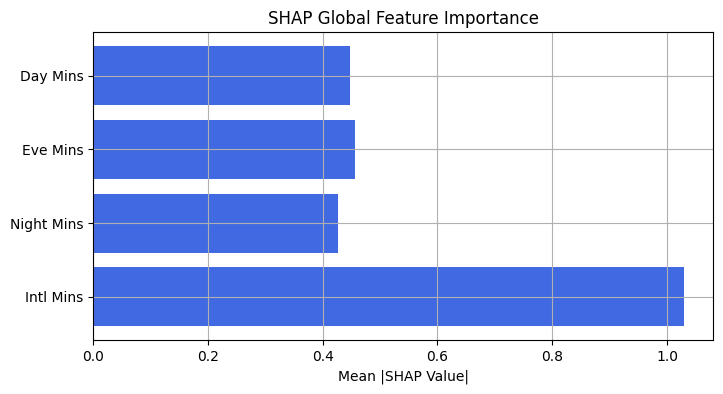


 Example Customer: 755-6955 → ML Recommended Plan: Value_5_₹199_Postpaid


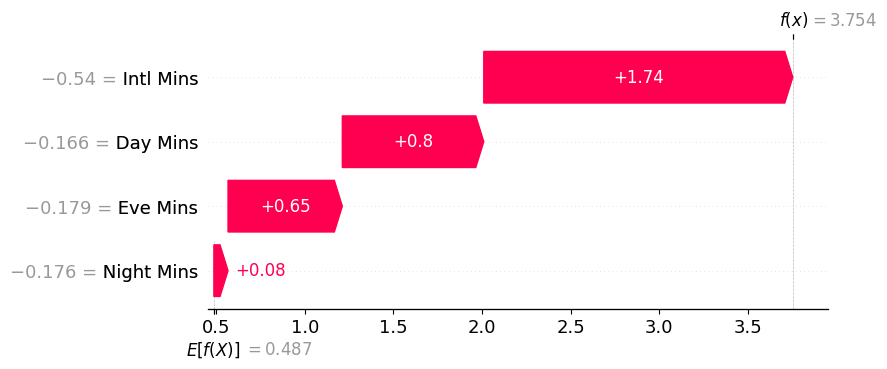

In [ ]:
# SHAP Explainability
print("\n  SHAP explainability...")
X_sample = X_test[:200]
explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)

global_imp = np.abs(shap_values.values).mean(axis=(0,2))
plt.figure(figsize=(8,4))
plt.barh(feat_cols, global_imp, color="royalblue")
plt.title("SHAP Global Feature Importance")
plt.xlabel("Mean |SHAP Value|")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

# Waterfall for first customer
i = 0
pred_class = np.argmax(probs_test[i])
original_pred_class = inverse_label_map[pred_class]
print(f"\n Example Customer: {df_test.iloc[i]['Phone Number']} → ML Recommended Plan: {df_postpaid.iloc[original_pred_class]['name']}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values.values[i, :, pred_class],
        base_values=shap_values.base_values[i, pred_class],
        data=X_test[i],
        feature_names=feat_cols
    )
)


In [ ]:
# USER INPUT + RECOMMENDATION ENGINE
try:
    day_mins = float(input("Enter your Day Minutes (default=250): ") or 250)
    eve_mins = float(input("Enter your Evening Minutes (default=200): ") or 200)
    night_mins = float(input("Enter your Night Minutes (default=300): ") or 300)
    intl_mins = float(input("Enter your International Minutes (default=10): ") or 10)
except ValueError:
    print(" Invalid input. Using defaults.")
    day_mins, eve_mins, night_mins, intl_mins = 250, 200, 300, 10

user_usage = {
    "Day Mins": day_mins,
    "Eve Mins": eve_mins,
    "Night Mins": night_mins,
    "Intl Mins": intl_mins
}

print(f"\n Your Usage: Day={day_mins}, Eve={eve_mins}, Night={night_mins}, Intl={intl_mins}")
print(f" Plan Type: Postpaid (Only Postpaid plans available)")

plans_filtered = plans_postpaid

# Cost-Based Ranking
user_scores_cost = []
for plan in plans_filtered:
    total_score = customer_plan_score(user_usage, plan, include_overage_cost=True)
    fit_quality = get_fit_quality_label(user_usage, plan)
    user_scores_cost.append({
        "plan_name": plan["name"],
        "monthly_fee": plan["monthly_fee"],
        "total_score": total_score,
        "fit_quality": fit_quality,
        "plan": plan,
        "source": "Cost-Based"
    })

user_scores_cost_sorted = sorted(user_scores_cost, key=lambda x: x["total_score"])
top3_cost = user_scores_cost_sorted[:3]

# ML-Based Ranking
top3_ml = []
try:
    user_input_df = pd.DataFrame([[day_mins, eve_mins, night_mins, intl_mins]], columns=feat_cols)
    user_input_scaled = scaler_ml.transform(user_input_df)
    probs = model.predict_proba(user_input_scaled)[0]
    pred_ranked = np.argsort(-probs)[:3]

    original_indices = [inverse_label_map[i] for i in pred_ranked if i in inverse_label_map]
    ml_top3_names = [df_postpaid.iloc[i]["name"] for i in original_indices if i < len(df_postpaid)]

    for plan_name in ml_top3_names:
        plan = next((p for p in plans_postpaid if p["name"] == plan_name), None)
        if plan is None:
            continue
        total_score = customer_plan_score(user_usage, plan, include_overage_cost=True)
        fit_quality = get_fit_quality_label(user_usage, plan)
        top3_ml.append({
            "plan_name": plan_name,
            "monthly_fee": plan["monthly_fee"],
            "total_score": total_score,
            "fit_quality": fit_quality,
            "plan": plan,
            "source": "ML-Based"
        })
except Exception as e:
    print(f" ML ranking failed: {e}")

# FINAL RANKING
acceptable_plans = []
seen_plans = set()

for item in top3_cost + top3_ml:
    if item["plan_name"] not in seen_plans:
        acceptable_plans.append(item)
        seen_plans.add(item["plan_name"])

for item in acceptable_plans:
    if item["source"] == "ML-Based":
        item["adjusted_score"] = item["total_score"] * 0.95 - 50  # 5% + ₹50 boost
    else:
        item["adjusted_score"] = item["total_score"]

sorted_plans = sorted(acceptable_plans, key=lambda x: x["adjusted_score"])

# Ensure diversity
ml_plans = [p for p in sorted_plans if p["source"] == "ML-Based"]
cost_plans = [p for p in sorted_plans if p["source"] == "Cost-Based"]

final_top3 = []
added_ml = False
seen_in_final = set()

# First pass
for plan in sorted_plans:
    if len(final_top3) >= 3:
        break
    if plan["plan_name"] in seen_in_final:
        continue
    if plan["source"] == "ML-Based" and not added_ml:
        final_top3.append(plan)
        seen_in_final.add(plan["plan_name"])
        added_ml = True
    elif plan["source"] == "Cost-Based" and len(final_top3) < 3:
        final_top3.append(plan)
        seen_in_final.add(plan["plan_name"])

# Second pass
if len(final_top3) < 3:
    for plan in sorted_plans:
        if len(final_top3) >= 3:
            break
        if plan["plan_name"] in seen_in_final:
            continue
        final_top3.append(plan)
        seen_in_final.add(plan["plan_name"])

# Force ML if none selected
if not added_ml and ml_plans:
    for plan in ml_plans:
        if plan["plan_name"] not in seen_in_final:
            if len(final_top3) >= 3:
                final_top3[-1] = plan  # replace last
            else:
                final_top3.append(plan)
            seen_in_final.add(plan["plan_name"])
            added_ml = True
            break

# Fallback generic if needed
if len(final_top3) < 3:
    for plan in plans_filtered:
        if len(final_top3) >= 3:
            break
        plan_name = plan["name"]
        if plan_name in seen_in_final:
            continue
        dummy_item = {
            "plan_name": plan_name,
            "monthly_fee": plan["monthly_fee"],
            "total_score": customer_plan_score(user_usage, plan, include_overage_cost=True),
            "fit_quality": get_fit_quality_label(user_usage, plan),
            "plan": plan,
            "source": "Fallback",
            "adjusted_score": customer_plan_score(user_usage, plan, include_overage_cost=True)
        }
        final_top3.append(dummy_item)
        seen_in_final.add(plan_name)

final_top3 = final_top3[:3]

# Final Output
print(f"\n YOUR PERSONALIZED TOP 3 PLANS (Usage Fit First, Then Price):\n")
for rank, item in enumerate(final_top3, 1):
    plan = item["plan"]
    badge = " Popular Plan" if int(item['monthly_fee']) in POPULAR_TIERS else ""
    print(f"Rank #{rank}: {item['plan_name']} ({item['source']}) {badge}".strip())
    print(f"    Monthly Cost: ₹{item['monthly_fee']:.2f}")
    print(f"    Fit Quality: {item['fit_quality']}")

    score_display = f"₹{item['total_score']:.2f}"
    if item["source"] == "ML-Based":
        score_display += f" → Personalized (ranked as ₹{item['adjusted_score']:.2f})"
    print(f"    Value Score: {score_display} (Lower is better — Usage fit prioritized)")

    print(f"    Includes: Day={plan['included_day']}min, Eve={plan['included_eve']}min, "
          f"Night={plan['included_night']}min, Intl={plan['included_intl']}min")

    # Postpaid overage logic
    overage = 0
    reasons = []
    for period in ["day", "eve", "night", "intl"]:
        used = user_usage[f"{period.capitalize()} Mins"]
        incl = plan[f"included_{period}"]
        if used > incl:
            overage += (used - incl) * plan[f"base_rate_{period}"] * plan["overage_mult"]
            reasons.append(f"{period.capitalize()} over by {used - incl:.0f}min")
    if overage > 0:
        print(f"    Overage Charges: ₹{overage:.2f} ({'; '.join(reasons)})")
    else:
      print(f"    No overage charges — usage within allowance!")


Enter your Day Minutes (default=250): 400
Enter your Evening Minutes (default=200): 300
Enter your Night Minutes (default=300): 100
Enter your International Minutes (default=10): 30

 Your Usage: Day=400.0, Eve=300.0, Night=100.0, Intl=30.0
 Plan Type: Postpaid (Only Postpaid plans available)

 YOUR PERSONALIZED TOP 3 PLANS (Usage Fit First, Then Price):

Rank #1: Comfort_0_₹399_Postpaid (Cost-Based)  Popular Plan
    Monthly Cost: ₹399.00
    Fit Quality: Good Fit
    Value Score: ₹475.19 (Lower is better — Usage fit prioritized)
    Includes: Day=400.0min, Eve=420.0min, Night=420.0min, Intl=30.0min
    No overage charges — usage within allowance!
Rank #2: Value_5_₹199_Postpaid (ML-Based)  Popular Plan
    Monthly Cost: ₹199.00
    Fit Quality:  Overage Risk
    Value Score: ₹666.54 → Personalized (ranked as ₹583.21) (Lower is better — Usage fit prioritized)
    Includes: Day=240.0min, Eve=260.0min, Night=260.0min, Intl=10.0min
    Overage Charges: ₹46.00 (Day over by 160min; Eve over

## Conclusion

The project successfully builds an **end-to-end tariff recommendation system**:

- Cleans and analyzes large call-detail data.
- Segments customers for data-driven plan creation.
- Implements both distance-based and XGBoost models for accurate plan prediction.

